# 02_data_preprocessing

Extracts raw band statistics from Planet satellite images at each CTD sampling point.

In [27]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import PowerTransformer
import geopandas as gpd

## Configuration

In [28]:
file_path = Path("../data/datasets/turbidity_ctd_satellite.csv")
out_dir = Path("../data/processed")
CTD_GEOJSON = Path("../geospatial/ctd_points_out5.geojson")

out_dir.mkdir(parents=True, exist_ok=True)

In [29]:
df = pd.read_csv(file_path)

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"])

target = "turbidity"
df[target] = pd.to_numeric(df[target], errors="coerce")

### Base dataset

This dataset contains the original cleaned CTD–satellite merged data without any transformation applied to the target variable.

It is used as a reference baseline to evaluate model performance under the original data distribution, which is highly skewed and contains extreme turbidity values.

In [30]:
df_base = df.copy()
df_base.to_csv(out_dir / "dataset_base.csv", index=False)

### Log-transformed dataset (log1p)

This dataset applies a log1p transformation to the turbidity variable.

It is used to reduce right skewness and stabilize variance, making the target distribution more suitable for regression models sensitive to outliers, such as gradient boosting methods.

In [31]:
df_log = df.copy()
df_log["turbidity"] = np.log1p(df_log[target])
df_log.to_csv(out_dir / "dataset_log1p.csv", index=False)

### Yeo-Johnson transformed dataset

This dataset applies a Yeo-Johnson power transformation to turbidity.

It is designed to handle strong skewness and heavy tails more flexibly than a log transform, while also supporting zero and near-zero values. It is expected to improve model stability and predictive accuracy.

In [32]:
pt = PowerTransformer(method="yeo-johnson")

df_yj = df.copy()
df_yj["turbidity"] = pt.fit_transform(df_yj[[target]]).ravel()
df_yj.to_csv(out_dir / "dataset_yeojohnson.csv", index=False)

### Trimmed dataset (1%–99% quantiles)

This dataset removes extreme outliers by filtering turbidity values outside the 1st and 99th percentiles.

It is used to reduce the influence of extreme events that may distort model training, while preserving the central distribution of the data.

In [33]:
df_trimmed = df.copy()

q_low = df_trimmed[target].quantile(0.01)
q_high = df_trimmed[target].quantile(0.99)

df_trimmed = df_trimmed[
    (df_trimmed[target] >= q_low) &
    (df_trimmed[target] <= q_high)
]

df_trimmed.to_csv(out_dir / "dataset_trimmed_1_99.csv", index=False)

## Load CTD sampling points

In [34]:
ctd = gpd.read_file(CTD_GEOJSON).set_crs("EPSG:4326")
print(f"CTD points loaded: {len(ctd)}")
ctd.head()

CTD points loaded: 11


,ControlPointCode,geometry
0,CTD1,POINT (-0.78448 37.8118)
1,CTD2,POINT (-0.8078 37.76062)
2,CTD3,POINT (-0.78355 37.76178)
3,CTD4,POINT (-0.74962 37.74823)
4,CTD6,POINT (-0.77838 37.71042)


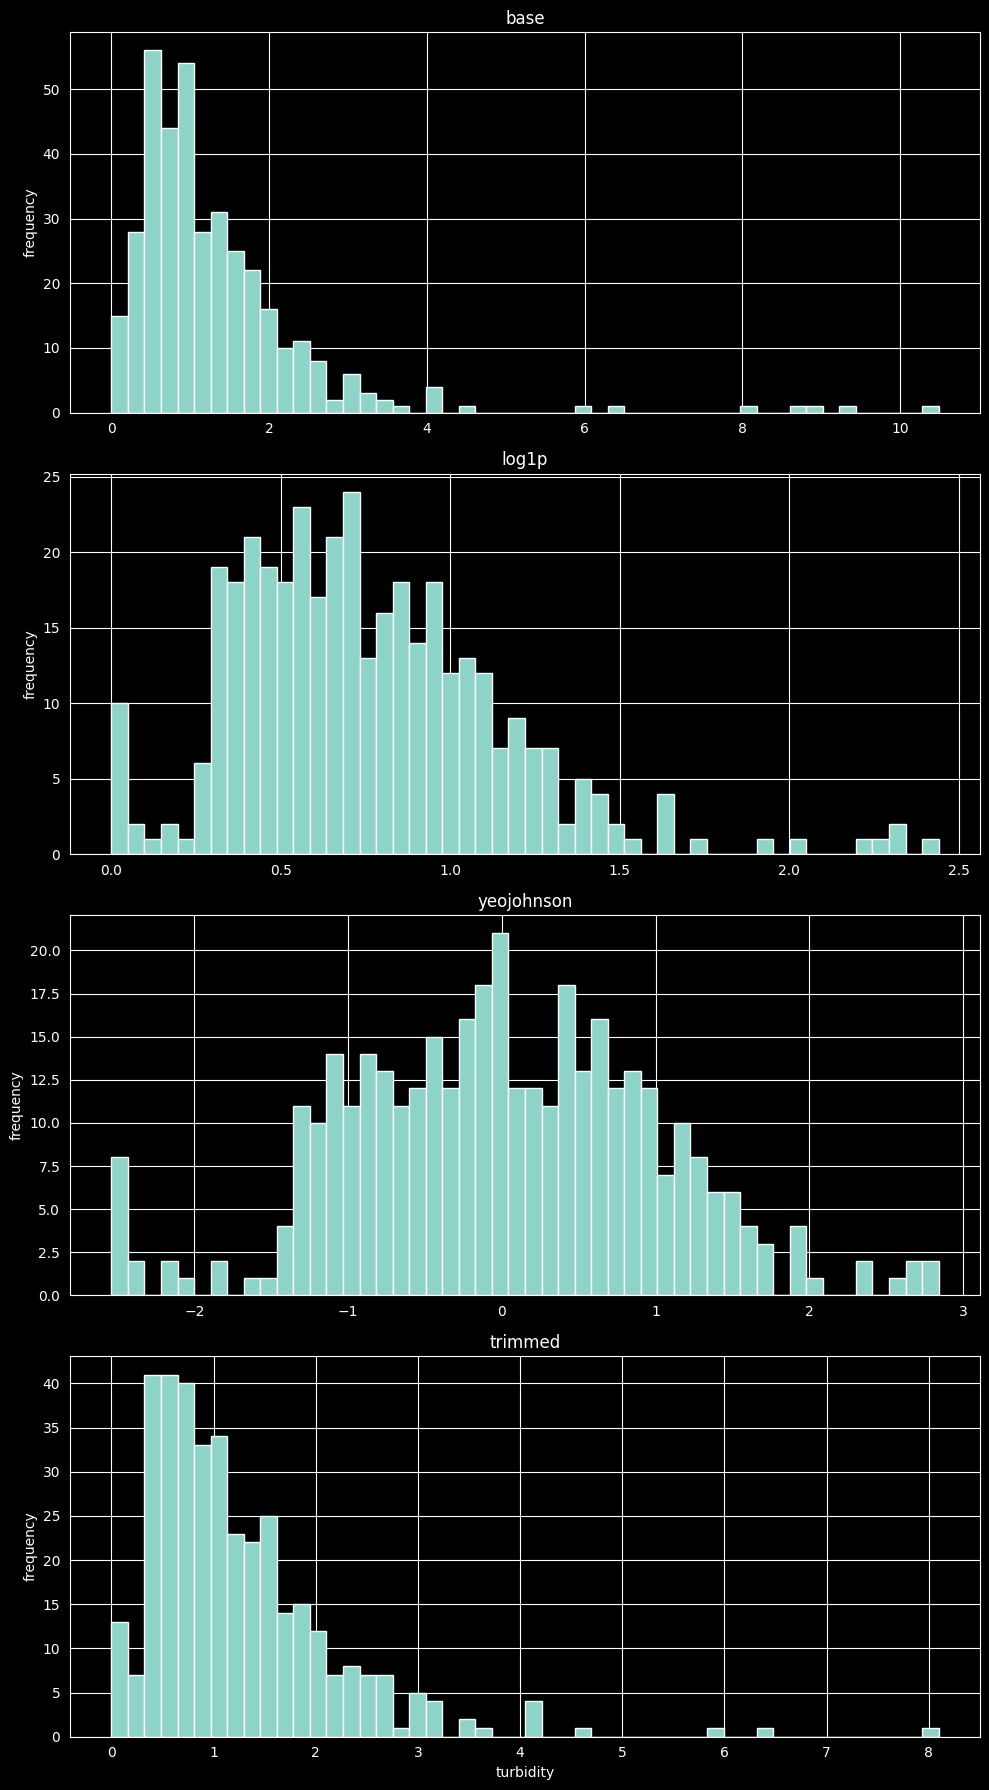

In [37]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

base_dir = Path("../data/processed")

datasets = {
    "base": "dataset_base.csv",
    "log1p": "dataset_log1p.csv",
    "yeojohnson": "dataset_yeojohnson.csv",
    "trimmed": "dataset_trimmed_1_99.csv"
}

target = "turbidity"

fig, axes = plt.subplots(len(datasets), 1, figsize=(10, 18), sharex=False)

for ax, (name, file) in zip(axes, datasets.items()):
    df = pd.read_csv(base_dir / file)
    x = pd.to_numeric(df[target], errors="coerce").dropna()

    ax.hist(x, bins=50)
    ax.set_title(name)
    ax.set_ylabel("frequency")

plt.xlabel("turbidity")
plt.tight_layout()
plt.show()